In [1]:
import pandas as pd
import numpy as np
import sklearn


df = pd.read_csv("../data/data_transformed_main.csv").set_index(["ID на сайте", "Источник"])
df["Вид объекта"] = df["Вид объекта"].replace({
    'Офис/Здание': 'Офис / Здание',
    'Торговое / Свободное назначение': 'Торговое / Свободного назначения',
    'Торговое / свободного вида': 'Торговое / Свободного назначения',
    'Торговое/Свободного назначения': 'Торговое / Свободного назначения',
})
df["Москва?"] = df["Москва?"].replace({'False': 0, 'True': 1}).astype(float)
df.head()

,,Цена,Дата,Тип автора,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Цена / м2,Москва?
ID на сайте,Источник,,,,,,,,,,,,,,,,,,
321970859,cian.ru,34500.0,2025-12-17 08:36:40,Агентство,Химки,Беломорская,"Рабочая ул., 2","НАЗВАНИЕ: Офис в Московская область, Химки Раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,9.167,4.0,4.0,Офис / Здание,23.0,1500.0,0.0
323570959,cian.ru,160500.0,2025-12-17 08:36:40,Частное лицо,Солнечногорск городской округ,Зеленоград — Крюково,21А,НАЗВАНИЕ: Торговая площадь в Московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,9.167,1.0,1.0,Торговое / Свободного назначения,107.0,1500.0,0.0
319937619,cian.ru,1226740.0,2025-12-17 08:36:40,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,9.167,2.0,6.0,Офис / Здание,830.0,1478.0,0.0
319936797,cian.ru,236480.0,2025-12-17 08:36:39,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,9.167,2.0,6.0,Офис / Здание,160.0,1478.0,0.0
319938233,cian.ru,1537120.0,2025-12-17 08:36:38,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,https://images.cdn-cian.ru/images/2569099478-1...,9.167,2.0,6.0,Офис / Здание,1040.0,1478.0,0.0


In [2]:
df.dtypes

Цена                       float64
Дата                        object
Тип автора                  object
Город                       object
Метро/Район                 object
Адрес                       object
Описание                    object
lat                        float64
lng                        float64
URL                         object
Ссылки на картинки          object
Расстояние до метро, км    float64
Этаж                       float64
Этажность здания           float64
Вид объекта                 object
Общая площадь              float64
Цена / м2                  float64
Москва?                    float64
dtype: object

In [3]:
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, TargetEncoder,
    StandardScaler, MinMaxScaler, RobustScaler,
)

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, QuantileRegressor
)

from sklearn.metrics import (
    r2_score,
    root_mean_squared_error as rmse,
    mean_absolute_percentage_error as mape,
)

In [4]:
df.columns

Index(['Цена', 'Дата', 'Тип автора', 'Город', 'Метро/Район', 'Адрес',
       'Описание', 'lat', 'lng', 'URL', 'Ссылки на картинки',
       'Расстояние до метро, км', 'Этаж', 'Этажность здания', 'Вид объекта',
       'Общая площадь', 'Цена / м2', 'Москва?'],
      dtype='object')

In [5]:
df.iloc[:2]["Тип автора"]

ID на сайте  Источник
321970859    cian.ru        Агентство
323570959    cian.ru     Частное лицо
Name: Тип автора, dtype: object

In [6]:
pd.get_dummies(df['Тип автора']).astype(int)

,,Агентство,Частное лицо
ID на сайте,Источник,,
321970859,cian.ru,1,0
323570959,cian.ru,0,1
319937619,cian.ru,1,0
319936797,cian.ru,1,0
319938233,cian.ru,1,0
...,...,...,...
4750280767,avito.ru,1,0
4750437026,avito.ru,1,0
4750004434,avito.ru,1,0


In [7]:
ohe = OneHotEncoder().fit(df[['Тип автора']])
ohe.transform(df[['Тип автора']]).toarray()

array([[1., 0.],
       [0., 1.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]], shape=(29559, 2))

In [8]:
ord_enc = OrdinalEncoder().fit(df[['Вид объекта']])
ord_enc.transform(df[['Вид объекта']])

array([[0.],
       [1.],
       [0.],
       ...,
       [0.],
       [0.],
       [1.]], shape=(29559, 1))

In [9]:
ord_enc.categories_

[array(['Офис / Здание', 'Торговое / Свободного назначения'], dtype=object)]

In [10]:
df.groupby("Вид объекта")["Цена"].mean()

Вид объекта
Офис / Здание                       496837.200929
Торговое / Свободного назначения    277255.474716
Name: Цена, dtype: float64

In [11]:
tar_enc = TargetEncoder(smooth=5).fit(df[['Вид объекта']], df["Цена"])
tar_enc.transform(df[['Вид объекта']])

array([[496754.84292232],
       [277272.21273862],
       [496754.84292232],
       ...,
       [496754.84292232],
       [496754.84292232],
       [277272.21273862]], shape=(29559, 1))

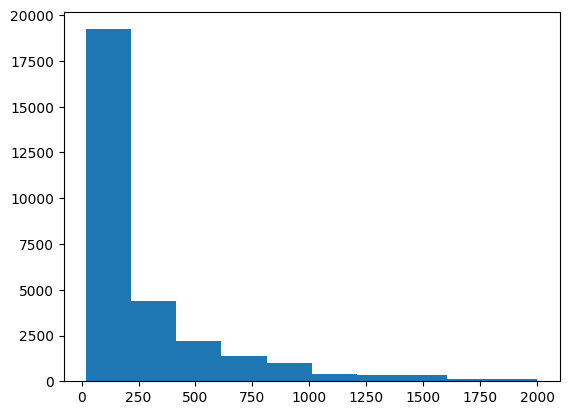

In [12]:
import matplotlib.pyplot as plt

plt.hist(df["Общая площадь"])
plt.show()

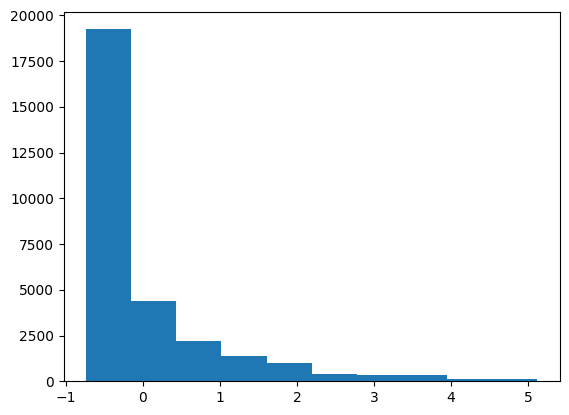

In [13]:
plt.hist(StandardScaler().fit_transform(df[["Общая площадь"]]))
plt.show()

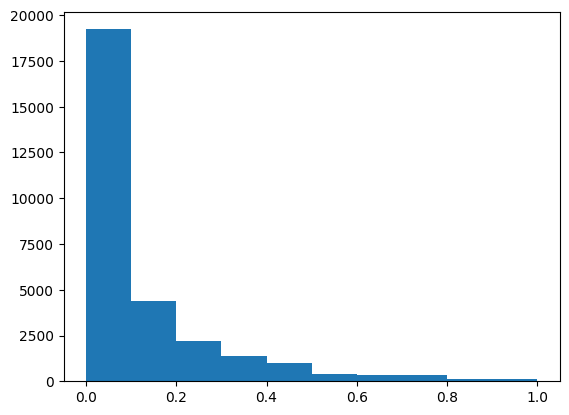

In [14]:
plt.hist(MinMaxScaler().fit_transform(df[["Общая площадь"]]))
plt.show()

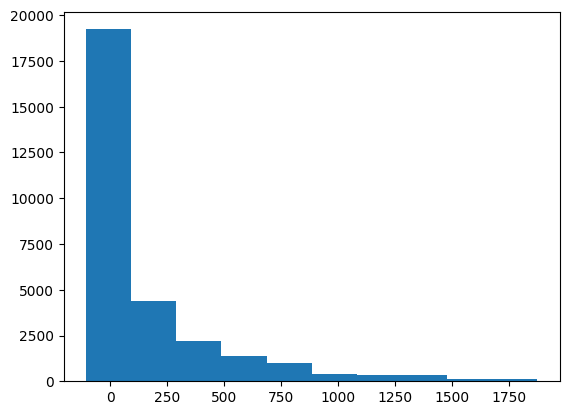

In [15]:
plt.hist(RobustScaler(quantile_range=(0.2, 0.8)).fit_transform(df[["Общая площадь"]]))
plt.show()

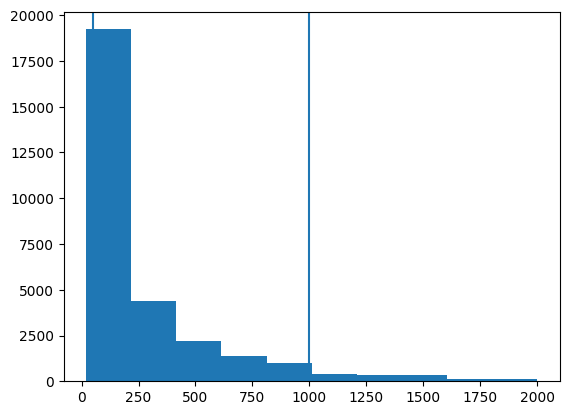

In [16]:
plt.hist(df["Общая площадь"])
plt.axvline(df["Общая площадь"].quantile(0.2))
plt.axvline(df["Общая площадь"].quantile(0.95))
plt.show()

In [17]:
df.columns

Index(['Цена', 'Дата', 'Тип автора', 'Город', 'Метро/Район', 'Адрес',
       'Описание', 'lat', 'lng', 'URL', 'Ссылки на картинки',
       'Расстояние до метро, км', 'Этаж', 'Этажность здания', 'Вид объекта',
       'Общая площадь', 'Цена / м2', 'Москва?'],
      dtype='object')

In [18]:
from sklearn.compose import ColumnTransformer

from sklearn import set_config
set_config(transform_output="pandas")

ct = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), ["Общая площадь", "Расстояние до метро, км"]),
        ("onehot", OneHotEncoder(sparse_output=False), ["Вид объекта"]),
        ("ordinal", OrdinalEncoder(), ["Тип автора"]),
    ],
    remainder="passthrough",
    n_jobs=-1,
).set_output(transform="pandas")

ct.fit(df)

,transformers,"[('scale', ...), ('onehot', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [19]:
ct.transform(df)

,,scale__Общая площадь,"scale__Расстояние до метро, км",onehot__Вид объекта_Офис / Здание,onehot__Вид объекта_Торговое / Свободного назначения,ordinal__Тип автора,remainder__Цена,remainder__Дата,remainder__Город,remainder__Метро/Район,remainder__Адрес,remainder__Описание,remainder__lat,remainder__lng,remainder__URL,remainder__Ссылки на картинки,remainder__Этаж,remainder__Этажность здания,remainder__Цена / м2,remainder__Москва?
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,
321970859,cian.ru,-0.727409,-0.071871,1.0,0.0,0.0,34500.0,2025-12-17 08:36:40,Химки,Беломорская,"Рабочая ул., 2","НАЗВАНИЕ: Офис в Московская область, Химки Раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,4.0,4.0,1500.000000,0.0
323570959,cian.ru,-0.479083,-0.071871,0.0,1.0,1.0,160500.0,2025-12-17 08:36:40,Солнечногорск городской округ,Зеленоград — Крюково,21А,НАЗВАНИЕ: Торговая площадь в Московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,1.0,1.0,1500.000000,0.0
319937619,cian.ru,1.658292,-0.071871,1.0,0.0,0.0,1226740.0,2025-12-17 08:36:40,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,2.0,6.0,1478.000000,0.0
319936797,cian.ru,-0.322401,-0.071871,1.0,0.0,0.0,236480.0,2025-12-17 08:36:39,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,2.0,6.0,1478.000000,0.0
319938233,cian.ru,2.279106,-0.071871,1.0,0.0,0.0,1537120.0,2025-12-17 08:36:38,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,https://images.cdn-cian.ru/images/2569099478-1...,2.0,6.0,1478.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4750280767,avito.ru,0.730322,-0.871338,1.0,0.0,0.0,736325.0,2025-02-28 14:19:30,Химки,Химки,"Московская обл., Химки, ул. Панфилова, 19с1",НАЗВАНИЕ: Офисное помещение 516.12 кв.м от соб...,55.881490,37.432933,https://www.avito.ru/himki/kommercheskaya_nedv...,https://30.img.avito.st/image/1/1.AlU-sba5rrwI...,1.0,NaN,1426.709940,0.0
4750437026,avito.ru,-0.256772,-0.838334,1.0,0.0,0.0,270000.0,2025-02-28 14:19:23,Котельники,Котельники,"Московская обл., Котельники, Дзержинское ш., 2",НАЗВАНИЕ: Офисное помещение 182.24 кв.м от соб...,55.654477,37.856443,https://www.avito.ru/kotelniki/kommercheskaya_...,https://10.img.avito.st/image/1/1.xz3K9La5a9T8...,5.0,NaN,1481.888035,0.0
4750004434,avito.ru,0.744808,-0.871338,1.0,0.0,0.0,743442.0,2025-02-28 14:19:06,Химки,Химки,"Московская обл., Химки, ул. Панфилова, 19с1",НАЗВАНИЕ: Офисное помещение 521 кв.м от собств...,55.881490,37.432933,https://www.avito.ru/himki/kommercheskaya_nedv...,https://70.img.avito.st/image/1/1.y5athra5Z3-b...,1.0,NaN,1426.952015,0.0


In [20]:
df.shape

(29559, 18)

In [21]:
from sklearn.model_selection import train_test_split

y = df["Цена"].copy()
X = df[["Общая площадь", "Расстояние до метро, км", "Вид объекта", "Тип автора", "Москва?"]].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=X["Вид объекта"])

In [22]:
X_train["Вид объекта"].value_counts() / X_train.shape[0] * 100

Вид объекта
Торговое / Свободного назначения    68.929586
Офис / Здание                       31.070414
Name: count, dtype: float64

In [23]:
X_test["Вид объекта"].value_counts() / X_test.shape[0] * 100

Вид объекта
Торговое / Свободного назначения    68.930988
Офис / Здание                       31.069012
Name: count, dtype: float64

In [24]:
X_test.isna().sum()

Общая площадь                 0
Расстояние до метро, км    2270
Вид объекта                   0
Тип автора                    0
Москва?                       0
dtype: int64

In [25]:
from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy="constant", fill_value=100, add_indicator=True).fit(X_train[["Расстояние до метро, км"]])
X_train_fillna = si.transform(X_train[["Расстояние до метро, км"]])
X_test_fillna = si.transform(X_test[["Расстояние до метро, км"]])

In [26]:
X_train = pd.concat([X_train.drop("Расстояние до метро, км", axis=1), X_train_fillna], axis=1)
X_test = pd.concat([X_test.drop("Расстояние до метро, км", axis=1), X_test_fillna], axis=1)

X_train.head()

,,Общая площадь,Вид объекта,Тип автора,Москва?,"Расстояние до метро, км","missingindicator_Расстояние до метро, км"
ID на сайте,Источник,,,,,,
323120883,cian.ru,20.0,Торговое / Свободного назначения,Агентство,0.0,100.000,1.0
7454557202,avito.ru,47.0,Торговое / Свободного назначения,Агентство,0.0,2.000,0.0
320599722,cian.ru,265.0,Офис / Здание,Агентство,0.0,1.833,0.0
325025163,cian.ru,58.0,Торговое / Свободного назначения,Частное лицо,0.0,10.083,0.0
7496482473,avito.ru,182.0,Торговое / Свободного назначения,Агентство,0.0,100.000,1.0


In [27]:
ct = ColumnTransformer(
    transformers=[
        
        ("scale", StandardScaler(), ["Общая площадь", "Расстояние до метро, км"]),
        ("onehot", OneHotEncoder(sparse_output=False), ["Вид объекта"]),
        ("ordinal", OrdinalEncoder(), ["Тип автора"]),
    ],
    remainder="passthrough",
    n_jobs=-1,
).set_output(transform="pandas")

ct.fit(X_train)

,transformers,"[('scale', ...), ('onehot', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [28]:
X_train_pre = ct.transform(X_train)
X_test_pre = ct.transform(X_test)

In [29]:
model = LinearRegression().fit(X_train_pre, y_train)
y_pred = model.predict(X_train_pre)
y_test_pred = model.predict(X_test_pre)

r2_score(y_train, y_pred), rmse(y_train, y_pred), mape(y_train, y_pred)

(0.7256526931762337, 220464.32655489852, 0.6968647268801466)

In [30]:
r2_score(y_test, y_test_pred), rmse(y_test, y_test_pred), mape(y_test, y_test_pred)

(0.7287563283488446, 222396.05922041662, 0.680853363947297)

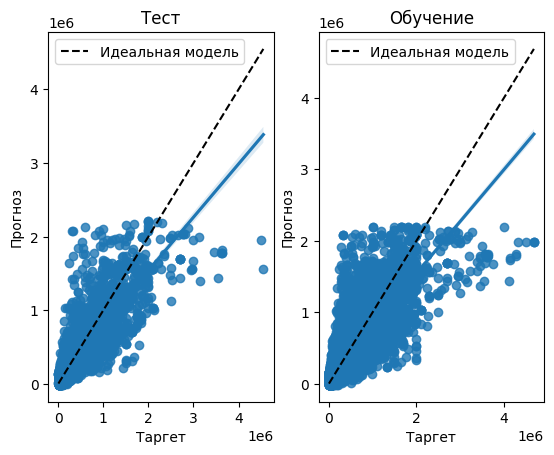

In [31]:
import seaborn as sns

fig, axis = plt.subplots(ncols=2)
sns.regplot(x=y_test, y=y_test_pred, ax=axis[0])
sns.regplot(x=y_train, y=y_pred, ax=axis[1])

for i, y_true in enumerate([y_test, y_train]):
    lims = [np.min(y_true), np.max(y_true)]
    axis[i].plot(lims, lims, linestyle="--", color="black", label="Идеальная модель")

axis[0].set_title("Тест")
axis[1].set_title("Обучение")
for i in [0, 1]:
    axis[i].set_xlabel("Таргет")
    axis[i].set_ylabel("Прогноз")
    axis[i].legend()
plt.show()

In [32]:
import sys

sys.path.append("..")

import viz

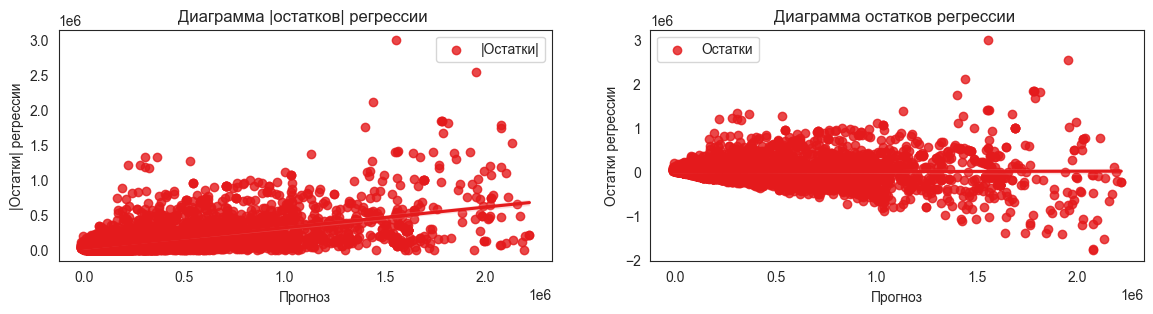

In [33]:
viz.plot_regression_residuals(y_test, y_test_pred)

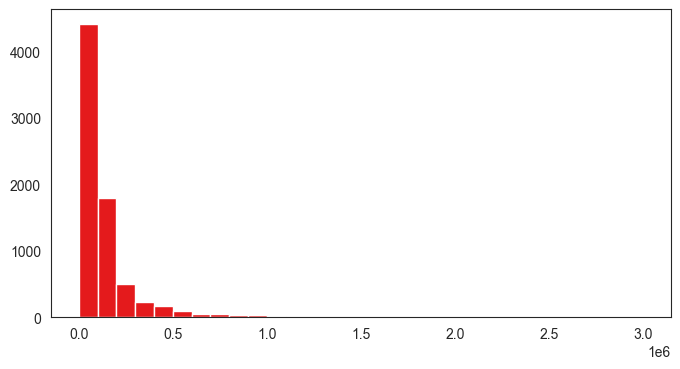

In [34]:
plt.hist(np.abs(y_test - y_test_pred), bins=30)
plt.show()

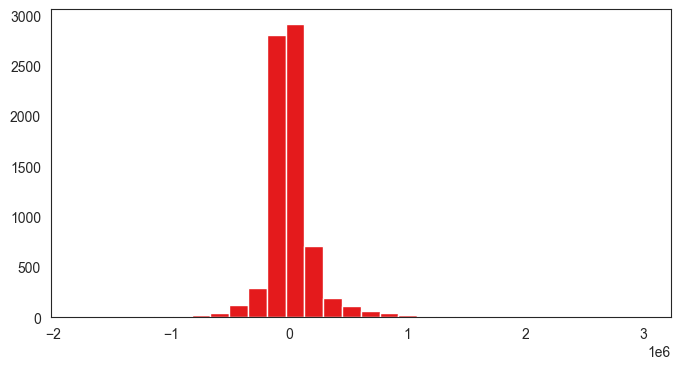

In [35]:
plt.hist(y_test - y_test_pred, bins=30)
plt.show()

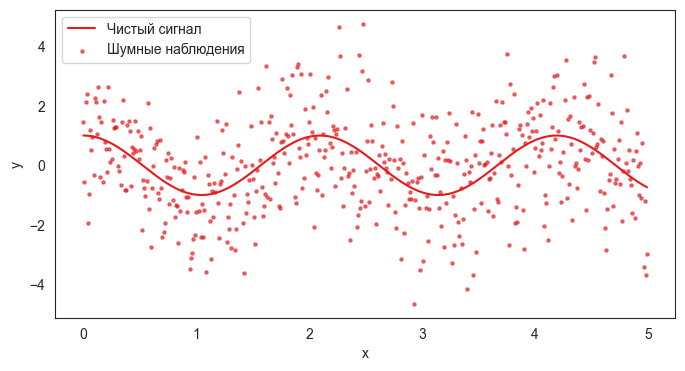

In [36]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)  # фиксируем сид для воспроизводимости

Xs = np.arange(0, 500) / 100
signal = np.cos(3 * Xs)

noise = rng.normal(loc=0.0, scale=1.5, size=len(Xs))  # N(0, 2^2)
ys = signal + noise

plt.figure(figsize=(8, 4))
plt.plot(Xs, signal, label="Чистый сигнал")
plt.scatter(Xs, ys, s=5, alpha=0.6, label="Шумные наблюдения")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

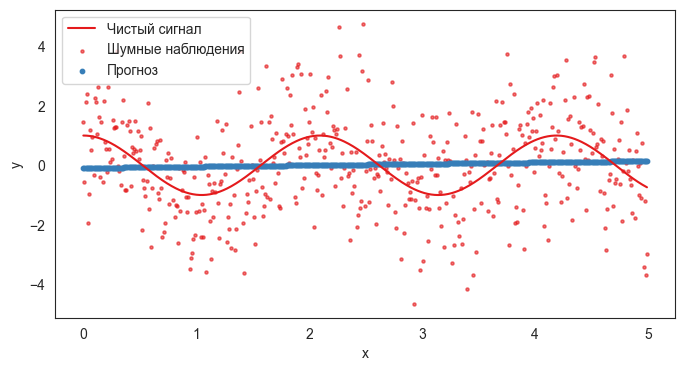

In [37]:
lrs = LinearRegression().fit(Xs.reshape(-1, 1), ys)
ys_pred = lrs.predict(Xs.reshape(-1, 1))

plt.figure(figsize=(8, 4))
plt.plot(Xs, signal, label="Чистый сигнал")
plt.scatter(Xs, ys, s=5, alpha=0.6, label="Шумные наблюдения")
plt.scatter(Xs, ys_pred, s=10, label="Прогноз")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

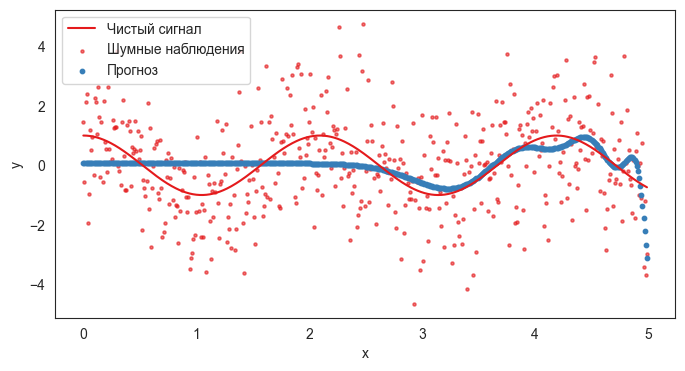

In [38]:
from sklearn.preprocessing import PolynomialFeatures

Xsp = PolynomialFeatures(degree=30).fit_transform(Xs.reshape(-1, 1)).drop("1", axis=1)

lrs = LinearRegression().fit(Xsp, ys)
ys_pred = lrs.predict(Xsp)

plt.figure(figsize=(8, 4))
plt.plot(Xs, signal, label="Чистый сигнал")
plt.scatter(Xs, ys, s=5, alpha=0.6, label="Шумные наблюдения")
plt.scatter(Xs, ys_pred, s=10, label="Прогноз")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [39]:
!pip install -q optuna

In [40]:
import optuna
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
optuna.logging.set_verbosity(optuna.logging.WARNING)


FIXED_KWARGS = {
    'tol': 1e-5,
    'random_state': 42,
}

CV = KFold(n_splits=5, random_state=10, shuffle=True)

def objective(trial, X, y):
    params = {
        'alpha': trial.suggest_float('alpha', low=0.0001, high=50),
        'max_iter': trial.suggest_int('max_iter', low=300, high=3000),
        'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']),
    }
    
    params.update(FIXED_KWARGS)
    model = Ridge(**params).fit(X, y)
    scores = cross_validate(
        model,
        X, y,
        scoring="r2", # https://scikit-learn.org/stable/modules/model_evaluation.html
        cv=CV,
        n_jobs=-1,
    )
    return scores['test_score'].mean()


def study_results(study):
    trial = study.best_trial
    print('Best CV={} score: {:.6}'.format(CV, trial.value))
    print('Best params:')
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))


def plot_study(study):
    fig_list = [
        optuna.visualization.plot_optimization_history(study),
        optuna.visualization.plot_param_importances(study),
    ]
    for fig in fig_list:
        fig.update_layout(width=900)
        fig.show()

In [41]:
# study = optuna.create_study(
#         sampler=optuna.samplers.TPESampler(),
#         pruner=optuna.pruners.HyperbandPruner(),
#         direction="maximize",
# )

# study.optimize(lambda trial: objective(trial, X_train_pre, y_train),
#                   n_trials=1000, timeout=300, gc_after_trial=True, show_progress_bar=True)

# study_results(study)
# plot_study(study)

In [42]:
# params = study.best_trial.params
# params.update(FIXED_KWARGS)

# model = Ridge(**params).fit(X_train_pre, y_train)
# y_test_pred = model.predict(X_test_pre)
# r2_score(y_test, y_test_pred), rmse(y_test, y_test_pred), mape(y_test, y_test_pred)

## CatBoost

In [43]:
!pip install -q catboost

In [44]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(verbose=False).fit(X_train_pre, y_train)
y_test_pred = model.predict(X_test_pre)
r2_score(y_test, y_test_pred), rmse(y_test, y_test_pred), mape(y_test, y_test_pred)

(0.7910823014925538, 195179.81257335746, 0.48729046858193886)

In [45]:
# FIXED_KWARGS = {
#     'logging_level': 'Silent',
#     'loss_function': 'RMSE',
#     'random_state': 10,
# }

# def objective(trial, X, y):
#     params = {
#         'iterations': trial.suggest_categorical('iterations', [50, 100, 200, 300, 500, 750, 1000]),
#         'depth': trial.suggest_int('depth', low=3, high=6),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', low=1e-6, high=100.0, log=True),
#         'learning_rate': trial.suggest_float('learning_rate', low=1e-4, high=5e-1), # log=True
#         'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', low=5, high=25),
#         'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.3, 1.0),
#         'subsample': trial.suggest_float('subsample', low=0.3, high=1.0),
#         'early_stopping_rounds': 200,
#     }
    
#     params.update(FIXED_KWARGS)
#     model = CatBoostRegressor(**params).fit(X, y)
#     scores = cross_validate(
#         model,
#         X, y,
#         scoring="r2", # https://scikit-learn.org/stable/modules/model_evaluation.html
#         cv=CV,
#         n_jobs=-1,
#     )
#     return scores['test_score'].mean()

In [46]:
# study = optuna.create_study(
#         sampler=optuna.samplers.TPESampler(),
#         pruner=optuna.pruners.HyperbandPruner(),
#         direction="maximize",
# )

# study.optimize(lambda trial: objective(trial, X_train_pre, y_train),
#                   n_trials=1000, timeout=1800, gc_after_trial=True, show_progress_bar=True)

# study_results(study)
# plot_study(study)

In [47]:
# params = study.best_trial.params
# params.update(FIXED_KWARGS)

# model = CatBoostRegressor(**params).fit(X_train_pre, y_train)
# y_test_pred = model.predict(X_test_pre)
# r2_score(y_test, y_test_pred), rmse(y_test, y_test_pred), mape(y_test, y_test_pred)

# Обработка текстов

In [48]:
!pip install -q nltk pymorphy2

In [49]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stops = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Oleg\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Обработка регулярками**

In [51]:
df["Описание2"] = df["Описание"].str.replace("НАЗВАНИЕ: ", "").str.replace("ОПИСАНИЕ: ", "").str.lower()
df["Описание2"] = df["Описание2"].str.replace(r"[^a-zа-яё\d]", " ", regex=True).str.replace(r"\d+", "", regex=True)
df["Описание2"] = df["Описание2"].str.replace(r"\s+", " ", regex=True)
df["Описание2"] = df["Описание2"].str.lower().str.strip()
df["Описание2"] = df["Описание2"].fillna("")

def replace_letter(text):
    for eng, ru in {
                    "a": "а",
                    "b": "в",
                    "c": "с",
                    "o": "о",
                    "y": "у",
                    "m": "м",
                    "e": "е",
                    "p": "р",
                    "h": "н",
                    "t": "т",
                    "x": "х",
                    "k": "к",
                }.items():
        text = text.replace(eng, ru)
    return text

df["Описание2"] = df["Описание2"].apply(replace_letter)

In [52]:
s = df.sample()
s["Описание2"].values[0]

'торговая площадь в московская область подольск комсомольская ул м объект в аренду предлагается торговое помещение площадью м по адресу московская обл подольск ул комсомольская д ключевые преимущества все коммуникации подойдет под любой вид деятельности инфраструктура альфа банк магазин хозтоваров парковка у павильона панорамное остекление удобные подъездные пути обеспечена большая проходимость возможность размещения рекламной вывески на фасаде основные характеристики площадь м чистовая отделка этаж этажность открытая планировка открытая территория квт электроэнергии высота потолков м класс здания в если у вас появились вопросы звоните на указанный номер наши ответственные будут рады вам помочь'

In [53]:
s["Описание"].values[0]

'НАЗВАНИЕ: Торговая площадь в Московская область, Подольск Комсомольская ул., 3 (59 м²)\r\n\r\nОПИСАНИЕ: Объект 11534 В аренду предлагается торговое помещение площадью 59м² по адресу: Московская обл., Подольск, ул Комсомольская, д 3 Ключевые преимущества: все коммуникации подойдет под любой вид деятельности инфраструктура: Альфа банк, магазин хозтоваров парковка у павильона панорамное остекление удобные подъездные пути обеспечена большая проходимость возможность размещения рекламной вывески на фасаде Основные характеристики: площадь: 59м² чистовая отделка этаж/этажность: 1/2 открытая планировка открытая территория 50 кВт электроэнергии высота потолков: 3.5м класс здания В Если у вас появились вопросы, звоните на указанный номер, наши ответственные будут рады Вам помочь '

In [54]:
import pymorphy2

morph = pymorphy2.MorphAnalyzer(lang='ru')

def get_norm_form(word):
    return morph.parse(word)[0].normal_form

def normalize_text(text):
    splitted = [get_norm_form(w) for w in text.split()]
    splitted = [w for w in splitted if w not in stops]
    return " ".join(splitted)

C:\Users\Oleg\AppData\Roaming\Python\Python310\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [55]:
%%time
df["Описание2"] = df["Описание2"].apply(normalize_text)
df[["Описание", "Описание2"]].to_excel("../data/Описания.xlsx")

CPU times: total: 18min 42s
Wall time: 18min 46s


**Разделение выборок**

In [56]:
X_train_pre.loc[:, "Описание2"] = df.loc[X_train_pre.index, "Описание2"]
X_test_pre.loc[:, "Описание2"] = df.loc[X_test_pre.index, "Описание2"]

**Удаление квантилей слов**

In [57]:
from nltk.probability import FreqDist

fd_counter = FreqDist()
_ = X_train_pre["Описание2"].apply(lambda text: fd_counter.update(text.split()))
len(fd_counter), fd_counter

(17424,
 FreqDist({'помещение': 60795, 'м': 57645, 'аренда': 36019, 'офис': 22703, 'свободный': 21091, 'площадь': 18961, 'назначение': 18472, 'этаж': 16931, 'московский': 16373, 'здание': 16262, ...}))

In [58]:
wc = pd.DataFrame(fd_counter.most_common(), columns=["word", "count"]).set_index("word")["count"]
wc.head(20)

word
помещение     60795
м             57645
аренда        36019
офис          22703
свободный     21091
площадь       18961
назначение    18472
этаж          16931
московский    16373
здание        16262
область       15518
кв            13690
центр         13277
торговый      12464
вход          12309
бизнес        11154
ул            10327
парковка       9945
первый         9265
сдаваться      8992
Name: count, dtype: int64

In [59]:
wc.sort_index()

word
d               144
ddх              18
dfiтuj            1
diffiсulтiеs      1
disратсна        12
               ... 
ящик              9
ящичек            2
ёлка              2
ёлочка            2
ёмкость          22
Name: count, Length: 17424, dtype: int64

In [60]:
wc.tail(20)

word
мжила                    1
помещенийпредлагаться    1
деньсвязаться            1
блинов                   1
смеситель                1
ручка                    1
дв                       1
мыло                     1
свобождение              1
спринкер                 1
газдевайс                1
ида                      1
капительный              1
скалоб                   1
видеонаблудения          1
уаснеjка                 1
внутрискалдский          1
гримёрный                1
вайлберрис               1
здрввсити                1
Name: count, dtype: int64

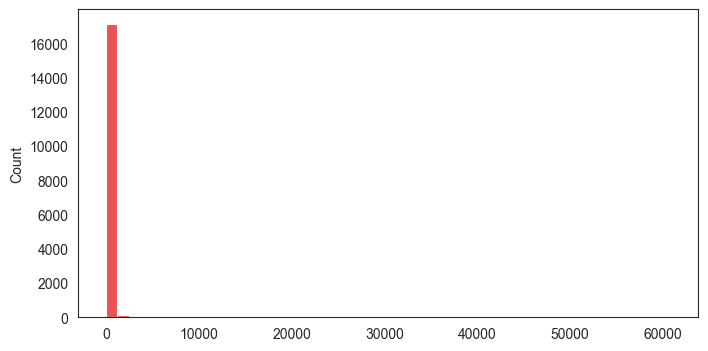

In [61]:
sns.histplot(wc.values, bins=50)
plt.show()

In [62]:
wc.describe(percentiles=(0.25, 0.5, 0.75, 0.8, 0.9))

count    17424.000000
mean       105.597107
std        952.355432
min          1.000000
25%          1.000000
50%          2.000000
75%         13.000000
80%         22.000000
90%         85.000000
max      60795.000000
Name: count, dtype: float64

**Фильтрация по числу вхождений**

In [200]:
LOW, HIGH = 5, 15000
vocab = {k: v for k, v in dict(fd_counter).items() if v <= HIGH and v >= LOW}
len(vocab)

6759

**Кластеризация + отрисовка**

In [201]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(vocabulary=list(vocab)).fit(X_train_pre["Описание2"].values)
train_bow = vectorizer.transform(X_train_pre["Описание2"].values)
test_bow = vectorizer.transform(X_test_pre["Описание2"].values)

train_bow

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1297458 stored elements and shape (22169, 6759)>

In [202]:
dict(sorted(vectorizer.vocabulary_.items(), key=lambda x: x[1])[::-1])

{'кувекино': 6758,
 'элли': 6757,
 'площадъ': 6756,
 'пивная': 6755,
 'голиковый': 6754,
 'чесноков': 6753,
 'учинскай': 6752,
 'кофемашин': 6751,
 'местановой': 6750,
 'металлург': 6749,
 'сесть': 6748,
 'нестеренко': 6747,
 'сенеж': 6746,
 'роза': 6745,
 'геоаналитик': 6744,
 'оценка': 6743,
 'марков': 6742,
 'примерный': 6741,
 'перепланировкидополнительный': 6740,
 'привыкнуть': 6739,
 'ф': 6738,
 'продвигаться': 6737,
 'равнодушный': 6736,
 'массивный': 6735,
 'мфтк': 6734,
 'заправочный': 6733,
 'статусный': 6732,
 'табачок': 6731,
 'ситуация': 6730,
 'аминьевский': 6729,
 'назначениятип': 6728,
 'задерживаться': 6727,
 'статусностипомещение': 6726,
 'традиция': 6725,
 'электрощитовой': 6724,
 'комбинат': 6723,
 'корнусов': 6722,
 'звягино': 6721,
 'самолетум': 6720,
 'молоденовый': 6719,
 'искра': 6718,
 'перехватывать': 6717,
 'саврасовый': 6716,
 'степанов': 6715,
 'аристовый': 6714,
 'овражек': 6713,
 'верзиловый': 6712,
 'решающий': 6711,
 'промышленно': 6710,
 'истранет': 6

In [239]:
from sklearn.decomposition import LatentDirichletAllocation as LDA

lda_kwargs = {
    'learning_method': 'online',
    'batch_size': 256,
    'learning_decay': 0.95,
    'n_components': 5,
    'random_state': 10,
    'max_iter': 20,
    'n_jobs': -1,
}

lda = LDA(**lda_kwargs).fit(train_bow)
labels_train_lda = np.argmax(lda.transform(train_bow), axis=1)
labels_test_lda = np.argmax(lda.transform(test_bow), axis=1)

In [240]:
!pip install -q wordcloud

In [241]:
from wordcloud import WordCloud

def draw_wordcloud(texts, max_words=1000, width=900, height=400, random_state=10):
    wordcloud = WordCloud(background_color='white', max_words=max_words,
                          width=width, height=height, random_state=random_state)

    joint_texts = ' '.join(list(texts))
    wordcloud.generate(joint_texts)
    return wordcloud.to_image()

def draw_cluster_clouds(texts_words, clusters, n_clusters, **cloud_kwargs):
    for k in range(n_clusters):
        inds = np.argwhere(clusters == k).reshape((-1,))
        print('cluster: {}; samples: {}'.format(k + 1, len(inds)))
        if len(inds) == 0:
            print('empty')
            continue
        display(draw_wordcloud(texts_words[inds], **cloud_kwargs))

In [242]:
words = vectorizer.get_feature_names_out()
text_words_count = train_bow.toarray()
text_words_mask = (text_words_count > 0)

reconstructed_texts = []
for mask in text_words_mask:
    reconstructed_texts.append(' '.join(words[mask]))
reconstructed_texts = np.asarray(reconstructed_texts)

cluster: 1; samples: 9907


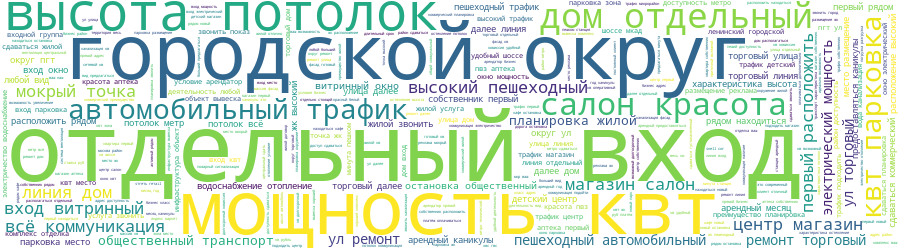

cluster: 2; samples: 2074


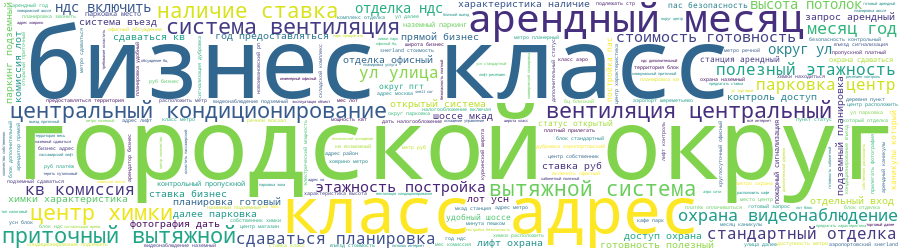

cluster: 3; samples: 1999


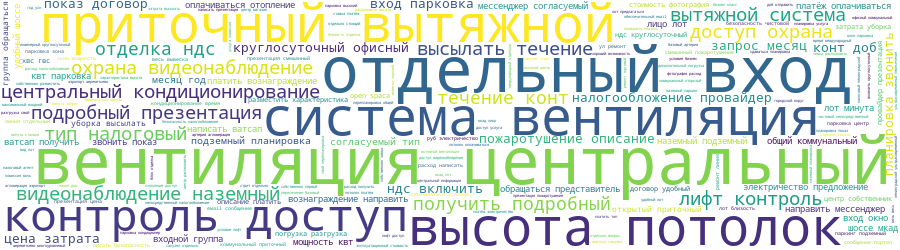

cluster: 4; samples: 2224


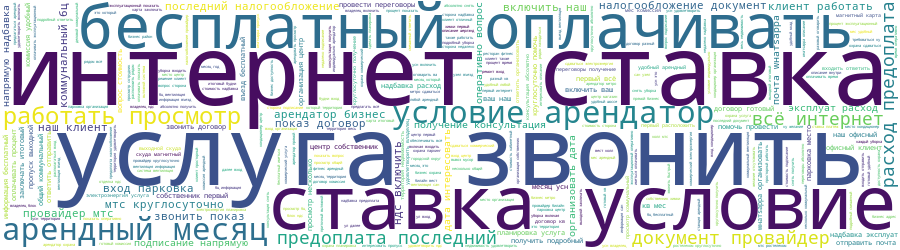

cluster: 5; samples: 5965


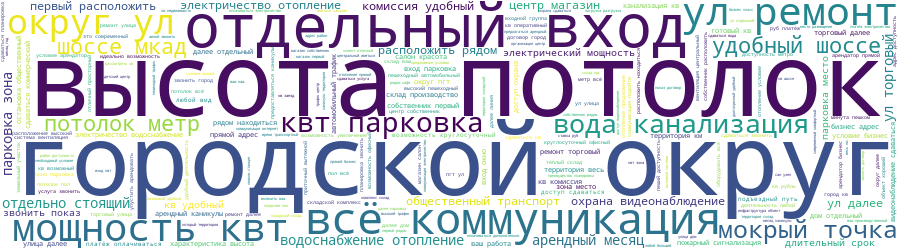

In [243]:
cloud_kwargs = { 'max_words': 300, 'width': 900, 'height': 250 }
draw_cluster_clouds(reconstructed_texts, labels_train_lda, lda_kwargs['n_components'], **cloud_kwargs)

In [244]:
X_train_lda = X_train_pre.drop("Описание2", axis=1)
X_test_lda = X_test_pre.drop("Описание2", axis=1)

model = LinearRegression().fit(X_train_lda, y_train)
y_pred = model.predict(X_train_lda)
y_test_pred = model.predict(X_test_lda)

print("train:")
print(r2_score(y_train, y_pred), rmse(y_train, y_pred), mape(y_train, y_pred))
print("test:")
print(r2_score(y_test, y_test_pred), rmse(y_test, y_test_pred), mape(y_test, y_test_pred))

train:
0.7256526931762337 220464.32655489852 0.6968647268801466
test:
0.7287563283488446 222396.05922041662 0.680853363947297


In [245]:
X_train_lda["desc_cluster"] = labels_train_lda
X_test_lda["desc_cluster"] = labels_test_lda

model = LinearRegression().fit(X_train_lda, y_train)
y_pred = model.predict(X_train_lda)
y_test_pred = model.predict(X_test_lda)

print("train:")
print(r2_score(y_train, y_pred), rmse(y_train, y_pred), mape(y_train, y_pred))
print("test:")
print(r2_score(y_test, y_test_pred), rmse(y_test, y_test_pred), mape(y_test, y_test_pred))

train:
0.7342457275385782 216984.19592897626 0.707929421921023
test:
0.7392950782368688 218032.8317157989 0.6881375889947836


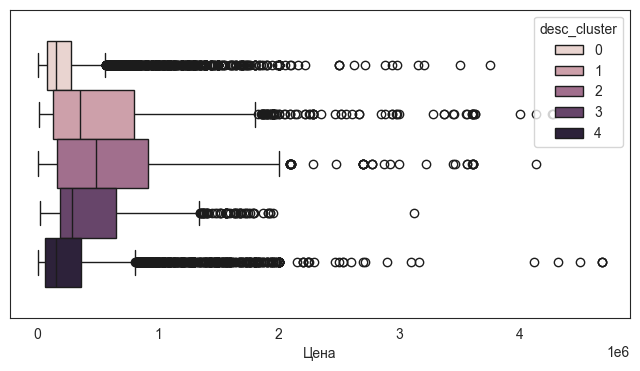

In [246]:
_ = sns.boxplot(x=y_train, hue=X_train_lda["desc_cluster"])